## Exercise 2

### Part 1

Sample mean: 1.9954
Theoretical mean: 2.0
Sample variance: 1.9543788399999997
Theoretical variance: 2.0


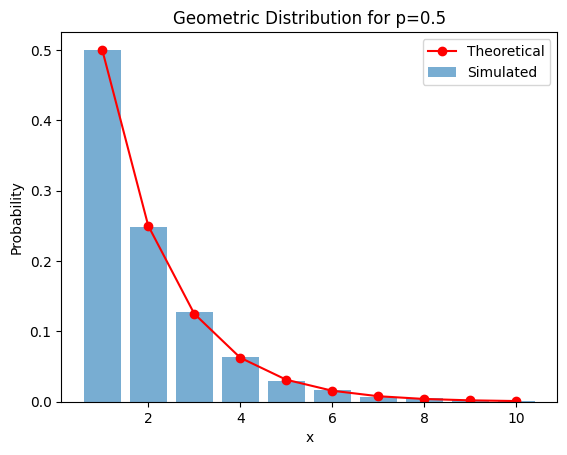

Chi-square statistic: 6.9754000000000005
p-value: 0.7277652860985807


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom, chisquare

# Moderate p-value
# Choose parameters
p = 0.5
n = 10000

# Simulate data from geometric distribution
data = np.random.geometric(p, n)


# Compare means and variances
print("Sample mean:", np.mean(data))
print("Theoretical mean:", 1/p)

print("Sample variance:", np.var(data))
print("Theoretical variance:", (1-p)/(p**2))


# Plot the comparison between probabilities
k = np.arange(1, 11)

# Simulated probabilities
sim_probs = [(data == i).mean() for i in k]

# Theoretical probabilities
theory_probs = geom.pmf(k, p)

plt.bar(k, sim_probs, alpha=0.6, label="Simulated")
plt.plot(k, theory_probs, 'ro-', label="Theoretical")
plt.xlabel("x")
plt.ylabel("Probability")
plt.title(f"Geometric Distribution for p={p}")
plt.legend()
plt.show()


# Chi-square test
observed = np.array([(data == i).sum() for i in range(1, 11)])
observed = np.append(observed, (data >= 11).sum())

expected = geom.pmf(np.arange(1, 11), p) * n
expected = np.append(expected, (1 - geom.cdf(10, p)) * n)

chi2, pvalue = chisquare(observed, expected)

print("Chi-square statistic:", chi2)
print("p-value:", pvalue)

Sample mean: 9.881
Theoretical mean: 10.0
Sample variance: 84.36823899999999
Theoretical variance: 89.99999999999999


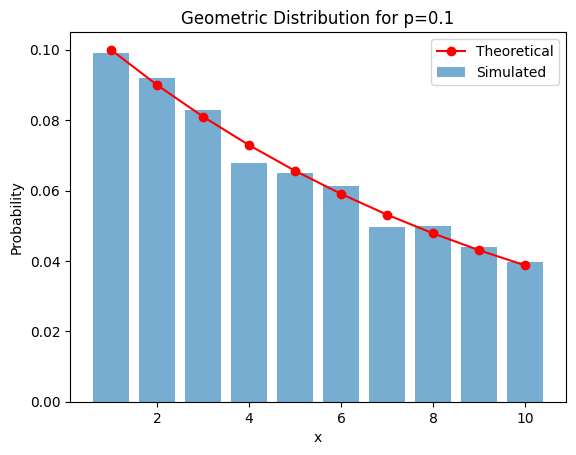

Chi-square statistic: 8.89860101257059
p-value: 0.5417530601741072


In [14]:
# Small p-value
# Choose parameters
p = 0.1
n = 10000

# Simulate data from geometric distribution
data = np.random.geometric(p, n)


# Compare means and variances
print("Sample mean:", np.mean(data))
print("Theoretical mean:", 1/p)

print("Sample variance:", np.var(data))
print("Theoretical variance:", (1-p)/(p**2))


# Plot the comparison between probabilities
k = np.arange(1, 11)

# Simulated probabilities
sim_probs = [(data == i).mean() for i in k]

# Theoretical probabilities
theory_probs = geom.pmf(k, p)

plt.bar(k, sim_probs, alpha=0.6, label="Simulated")
plt.plot(k, theory_probs, 'ro-', label="Theoretical")
plt.xlabel("x")
plt.ylabel("Probability")
plt.title(f"Geometric Distribution for p={p}")
plt.legend()
plt.show()


# Chi-square test
observed = np.array([(data == i).sum() for i in range(1, 11)])
observed = np.append(observed, (data >= 11).sum())

expected = geom.pmf(np.arange(1, 11), p) * n
expected = np.append(expected, (1 - geom.cdf(10, p)) * n)

chi2, pvalue = chisquare(observed, expected)

print("Chi-square statistic:", chi2)
print("p-value:", pvalue)

Sample mean: 1.1186
Theoretical mean: 1.1111111111111112
Sample variance: 0.13593403999999998
Theoretical variance: 0.12345679012345676


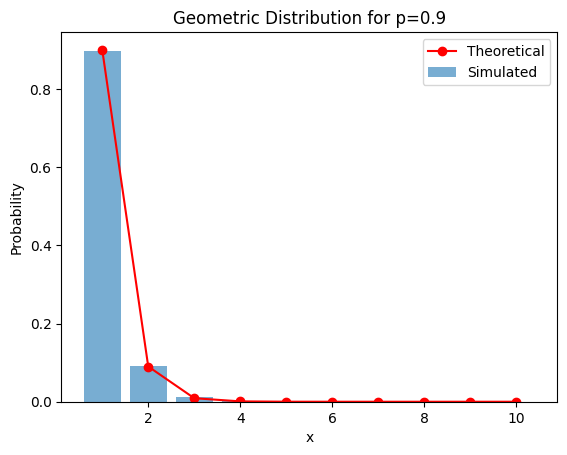

Chi-square statistic: 10.620666666666791
p-value: 0.38782458150744503


In [15]:
# Large p-value
# Choose parameters
p = 0.9
n = 10000

# Simulate data from geometric distribution
data = np.random.geometric(p, n)


# Compare means and variances
print("Sample mean:", np.mean(data))
print("Theoretical mean:", 1/p)

print("Sample variance:", np.var(data))
print("Theoretical variance:", (1-p)/(p**2))


# Plot the comparison between probabilities
k = np.arange(1, 11)

# Simulated probabilities
sim_probs = [(data == i).mean() for i in k]

# Theoretical probabilities
theory_probs = geom.pmf(k, p)

plt.bar(k, sim_probs, alpha=0.6, label="Simulated")
plt.plot(k, theory_probs, 'ro-', label="Theoretical")
plt.xlabel("x")
plt.ylabel("Probability")
plt.title(f"Geometric Distribution for p={p}")
plt.legend()
plt.show()


# Chi-square test
observed = np.array([(data == i).sum() for i in range(1, 11)])
observed = np.append(observed, (data >= 11).sum())

expected = geom.pmf(np.arange(1, 11), p) * n
expected = np.append(expected, (1 - geom.cdf(10, p)) * n)

chi2, pvalue = chisquare(observed, expected)

print("Chi-square statistic:", chi2)
print("p-value:", pvalue)

### Part 2

In [ ]:
# Six-point distribution
x = np.array([1, 2, 3, 4, 5, 6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])


# Direct (crude) method
n = 10000

cdf = np.cumsum(p)

u = np.random.rand(n)

samples_direct = np.zeros(n)

for i in range(n):
    samples_direct[i] = x[np.searchsorted(cdf, u[i])]


print("Direct method frequencies:")
print(np.bincount(samples_direct.astype(int))[1:])


# Rejection method (simple)
k = len(p)
c = max(p)   # Must satisfy c > max(p)
n = 10000
samples_rejection = []

while len(samples_rejection) < n:

    # Generate I
    I = np.random.randint(1, k+1)

    # Accept/reject
    u2 = np.random.rand()

    if u2 <= p[I-1] / c:
        samples_rejection.append(I)

samples_rejection = np.array(samples_rejection)


print("Rejection method frequencies:")
print(np.bincount(samples_rejection.astype(int))[1:])


# Alias method
n = 10000

K = len(p)
prob = p * K

alias = np.zeros(K, dtype=int)
prob_table = np.zeros(K)

small = []
large = []

for i in range(K):
    if prob[i] < 1:
        small.append(i)
    else:
        large.append(i)

while small and large:
    s = small.pop()
    l = large.pop()

    prob_table[s] = prob[s]
    alias[s] = l

    prob[l] = prob[l] - (1 - prob[s])

    if prob[l] < 1:
        small.append(l)
    else:
        large.append(l)

for i in small + large:
    prob_table[i] = 1

u1 = np.random.randint(0, K, n)
u2 = np.random.rand(n)

samples_alias = np.where(u2 < prob_table[u1], u1, alias[u1]) + 1


print("Alias method frequencies:")
print(np.bincount(samples_alias)[1:])

Direct method frequencies:
[1436 1084 1293  619 2471 3097]
Rejection method frequencies:
[1473 1090 1252  638 2487 3060]
Alias method frequencies:
[1477 1021 1212  629 2515 3146]


In [21]:
# Compare the three simulation methods
print("Theoretical probabilities:", p)

print("\nDirect:", np.bincount(samples_direct.astype(int))[1:] / n)
print("Rejection:", np.bincount(samples_rejection.astype(int))[1:] / n)
print("Alias:", np.bincount(samples_alias)[1:] / n)

Theoretical probabilities: [0.14583333 0.10416667 0.125      0.0625     0.25       0.3125    ]

Direct: [0.1436 0.1084 0.1293 0.0619 0.2471 0.3097]
Rejection: [0.1473 0.109  0.1252 0.0638 0.2487 0.306 ]
Alias: [0.1477 0.1021 0.1212 0.0629 0.2515 0.3146]


### Part 3

All three methods produce samples from the given discrete distribution, as seen by how close the empirical and theoretical probabilities are for all three methods. 

If we look at efficinecy, then the alias method is the most efficient for large-scale simulations due to its constant-time sampling. The direct method is then moderately efficient, while the rejection method is the least efficient due to potential sample rejections.

Regarding the ease of implementation, then the direct method is the easiest/simplest, which is then followed by the rejection method, while the alias method is the most difficult to implement due to its preprocessing requirements.

If we look at memoty usage, then the direct method and the rejection method don't require a lot of storage, while the alias method requires more storage for probability and alias tables.

### Part 4

The advantages of the direct method are that it's very easy to understand and implement, it has no complex pre-processing, it always produces correct samples, and it works well for small state samples, while its disandvanges are that it requires searching through cumulative probabilities, it becomes slow when the number of outcomes is large, and it's not efficient enough for high-performance simulations. The direct method is therefore preferred when the distribution is small and the ease of implementation is more important than efficiency.

The advantages of the rejection method are that it's flexible, it doesn't require cumulative probabilities, and it's easy to adapt to complex distributions, while its disadvantages are that it's inefficient if the accceptance rate is low, the number of iterations per sample is random, and it can waste many generated samples. The rejection method should therefore be used when direct inversion is not possible/difficult, escpecially for more complex or continuous distributions where other methods aren't available.

The advantages of the alias method are that it has very fast sampling, it's very efficient for repeated sampling, and it has no rejections, while its disadvantages are that it's more complex to implement correctly, it requires a pre-processing step, and it uses more memory. The alias method should therefore be used when many samples are required from a fixed discrete distribution, especially in large-scale simulations where efficiency is important.